In [1]:
# === STEP 0: Install and import packages ===
!pip install Bio
!pip install matplotlib_venn

import re
import requests
from collections import defaultdict
import pandas as pd
from datetime import datetime

# Optional plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# === STEP 1a: Download latest UniProt Human Proteome ===
# Reviewed proteins with reviewed isoforms
import requests
from datetime import datetime
import os

def download_human_reference_fasta(output_dir="."):
    # Hardcode the human reference proteome ID
    proteome_id = "UP000005640"
    species_short = "Human"
    
    # Output filename with date
    date_str = datetime.now().strftime("%y%m%d")
    filename = f"{species_short}_Proteome_{proteome_id}_{date_str}.fasta"
    output_path = os.path.join(output_dir, filename)
    
    # Build API request
    url = "https://rest.uniprot.org/uniprotkb/stream"
    params = {
        "query": f"((proteome:{proteome_id}) AND reviewed=true)",
        "format": "fasta",
        "includeIsoform": "true"
    }
    
    print(f"⬇️  Downloading Human reviewed reference proteome ({proteome_id}) ...")
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    # Save FASTA to file
    with open(output_path, "w") as f:
        f.write(response.text)
    
    print(f"✅ Saved: {output_path}")
    return output_path

# Usage:
download_human_reference_fasta(output_dir=".")



⬇️  Downloading Human reviewed reference proteome (UP000005640) ...
✅ Saved: ./Human_Proteome_UP000005640_251107.fasta


'./Human_Proteome_UP000005640_251107.fasta'

In [3]:
# === STEP 1b: Download latest UniProt Mouse Proteome ===
# Reviewed proteins with reviewed isoforms
import requests
from datetime import datetime
import os

def download_mouse_reference_fasta(output_dir="."):
    # Mouse reference proteome ID
    proteome_id = "UP000000589"
    species_short = "Mouse"
    
    # Output filename with date
    date_str = datetime.now().strftime("%y%m%d")
    filename = f"{species_short}_Proteome_{proteome_id}_{date_str}.fasta"
    output_path = os.path.join(output_dir, filename)
    
    # Build API request
    url = "https://rest.uniprot.org/uniprotkb/stream"
    params = {
        "query": f"((proteome:{proteome_id}) AND reviewed=true)",
        "format": "fasta",
        "includeIsoform": "true"
    }
    
    print(f"⬇️  Downloading Mouse reviewed reference proteome ({proteome_id}) ...")
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    # Save FASTA to file
    with open(output_path, "w") as f:
        f.write(response.text)
    
    print(f"✅ Saved: {output_path}")
    return output_path

# Usage:
download_mouse_reference_fasta(output_dir=".")


⬇️  Downloading Mouse reviewed reference proteome (UP000000589) ...
✅ Saved: ./Mouse_Proteome_UP000000589_251107.fasta


'./Mouse_Proteome_UP000000589_251107.fasta'

In [4]:
# === STEP 2: Define FASTA parsing and digest functions ===
def parse_fasta(fasta_path):
    """
    Parse FASTA into dict {protein_id: full_header, seq}
    """
    sequences = {}
    headers = {}
    with open(fasta_path) as fh:
        current_header = None
        current_seq = []
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                if current_header:
                    sequences[current_header] = "".join(current_seq)
                # extract protein ID from UniProt header
                m = re.match(r"^>[^|]+\|[A-Z0-9]+\|([^ ]+)", line)
                if m:
                    pid = m.group(1)
                    current_header = pid
                    headers[pid] = line
                current_seq = []
            else:
                current_seq.append(line)
        if current_header:
            sequences[current_header] = "".join(current_seq)
    return headers, sequences


def trypsin_lys_c_digest(sequence, min_len=6, max_len=50):
    """
    In-silico digest using Trypsin and Lys-C:
    - Trypsin: cleaves after K/R unless followed by P
    - Lys-C: cleaves after K unless followed by P
    """
    import re
    # Trypsin: cut after K or R, not before P
    trypsin_pattern = r'(?<=[KR])(?!P)'
    peptides_trypsin = re.split(trypsin_pattern, sequence)
    
    # Lys-C: cut after K, not before P
    lysc_pattern = r'(?<=[K])(?!P)'
    peptides_lysc = re.split(lysc_pattern, sequence)
    
    # Combine and keep unique, filter length
    peptides = set(peptides_trypsin + peptides_lysc)
    peptides = {p for p in peptides if min_len <= len(p) <= max_len}
    return peptides

In [5]:
# === STEP 3: Load FASTAs directly from files written by previous step ===

# Call the download functions and capture the file paths
human_fasta = download_human_reference_fasta(output_dir=".")
mouse_fasta = download_mouse_reference_fasta(output_dir=".")

# Now parse the FASTAs
human_headers, human_seqs = parse_fasta(human_fasta)
mouse_headers, mouse_seqs = parse_fasta(mouse_fasta)

print(f"Human proteins: {len(human_seqs)}, Mouse proteins: {len(mouse_seqs)}")


⬇️  Downloading Human reviewed reference proteome (UP000005640) ...
✅ Saved: ./Human_Proteome_UP000005640_251107.fasta
⬇️  Downloading Mouse reviewed reference proteome (UP000000589) ...
✅ Saved: ./Mouse_Proteome_UP000000589_251107.fasta
Human proteins: 20405, Mouse proteins: 17234


In [6]:
# === STEP 3: Digest all proteins ===
human_peptides = defaultdict(set)
mouse_peptides = defaultdict(set)

for pid, seq in human_seqs.items():
    human_peptides[pid] = trypsin_lys_c_digest(seq)

for pid, seq in mouse_seqs.items():
    mouse_peptides[pid] = trypsin_lys_c_digest(seq)

In [7]:
# === STEP 4: Build peptide→protein mapping ===
pep_to_human = defaultdict(set)
pep_to_mouse = defaultdict(set)

for pid, peptides in human_peptides.items():
    for pep in peptides:
        pep_to_human[pep].add(pid)

for pid, peptides in mouse_peptides.items():
    for pep in peptides:
        pep_to_mouse[pep].add(pid)

In [8]:
# === STEP 5: Classify peptides as human-unique, mouse-unique, or shared ===
all_peptides = set(list(pep_to_human.keys()) + list(pep_to_mouse.keys()))
peptide_records = []

for pep in all_peptides:
    human_ids = pep_to_human.get(pep, set())
    mouse_ids = pep_to_mouse.get(pep, set())
    if human_ids and not mouse_ids:
        origin = "human-unique"
    elif mouse_ids and not human_ids:
        origin = "mouse-unique"
    else:
        origin = "shared"
    peptide_records.append({
        "peptide": pep,
        "human_proteins": ",".join(human_ids),
        "mouse_proteins": ",".join(mouse_ids),
        "origin": origin
    })

df_peptides = pd.DataFrame(peptide_records)
print(f"Total peptides: {len(df_peptides)}")

Total peptides: 1180832


In [9]:
# === STEP 6: Aggregate peptides per protein (three-entry structure) ===
def get_root(pid):
    return pid.split("_")[0] if "_" in pid else pid

human_prot_peps = defaultdict(set)
mouse_prot_peps = defaultdict(set)
shared_prot_peps = defaultdict(set)

for _, row in df_peptides.iterrows():
    pep = row["peptide"]
    origin = row["origin"]
    human_ids = [pid for pid in row["human_proteins"].split(",") if pid]
    mouse_ids = [pid for pid in row["mouse_proteins"].split(",") if pid]

    if origin == "human-unique":
        for pid in human_ids:
            human_prot_peps[pid].add(pep)
    elif origin == "mouse-unique":
        for pid in mouse_ids:
            mouse_prot_peps[pid].add(pep)
    elif origin == "shared":
        roots = set([get_root(pid) for pid in human_ids + mouse_ids])
        for root in roots:
            shared_prot_peps[root + "_SHARED"].add(pep)

# Ensure all proteins have placeholders to match root
all_roots = set(get_root(pid) for pid in list(human_prot_peps)+list(mouse_prot_peps))
for root in all_roots:
    human_prot_peps.setdefault(f"{root}_HUMAN", set())
    mouse_prot_peps.setdefault(f"{root}_MOUSE", set())
    shared_prot_peps.setdefault(f"{root}_SHARED", set())

In [10]:
# === STEP 7: Build combined header lookup ===
header_lookup = {}
for pid, header in human_headers.items():
    header_lookup[pid] = header
for pid, header in mouse_headers.items():
    header_lookup[pid] = header

In [11]:
# === STEP 8: Validate shared entries (keep only if human or mouse exists) ===
def validate_shared_entries(human_dict, mouse_dict, shared_dict):
    valid_shared = {}
    for pid, peps in shared_dict.items():
        if not peps:
            continue
        root = pid.replace("_SHARED","")
        if f"{root}_HUMAN" in human_dict or f"{root}_MOUSE" in mouse_dict:
            valid_shared[pid] = peps
    return valid_shared

shared_prot_peps = validate_shared_entries(human_prot_peps, mouse_prot_peps, shared_prot_peps)

In [12]:
# === STEP 9: Write combined Spectronaut-safe FASTA ===
def extract_accession(header_line):
    m = re.search(r"\|([A-Z0-9]+)\|", header_line)
    return m.group(1) if m else "UNKNOWN"

def clean_description(header_line):
    return re.sub(r"^>[^|]+\|[A-Z0-9]+\|[^ ]+\s*", "", header_line).strip()

def write_spectronaut_fasta(out_fasta, human_dict, mouse_dict, shared_dict, header_lookup, spacer=""):
    def write_entry(fh, acc, pid, origin, n_peptides, desc, seq):
        fh.write(f">sp|{acc}|{pid}|origin={origin}|n_peptides={n_peptides} {desc}\n{seq}\n")

    with open(out_fasta, "w") as f:
        for pid, peps in sorted(human_dict.items()):
            if not peps: continue
            if pid not in header_lookup: continue
            header = header_lookup[pid]
            acc = extract_accession(header)
            desc = clean_description(header)
            seq = spacer.join(sorted(peps, key=len))
            write_entry(f, acc, pid, "human-unique", len(peps), desc, seq)

        for pid, peps in sorted(mouse_dict.items()):
            if not peps: continue
            if pid not in header_lookup: continue
            header = header_lookup[pid]
            acc = extract_accession(header)
            desc = clean_description(header)
            seq = spacer.join(sorted(peps, key=len))
            write_entry(f, acc, pid, "mouse-unique", len(peps), desc, seq)

        for pid, peps in sorted(shared_dict.items()):
            if not peps: continue
            root = pid.replace("_SHARED","")
            ref_header = header_lookup.get(f"{root}_HUMAN") or header_lookup.get(f"{root}_MOUSE")
            if not ref_header: continue
            acc = extract_accession(ref_header) + "-sh"
            desc = f"Shared Human-Mouse Ortholog ({clean_description(ref_header)})"
            seq = spacer.join(sorted(peps, key=len))
            write_entry(f, acc, pid, "shared", len(peps), desc, seq)

output_fasta = "combined_human_mouse_proteotypic.fasta"
write_spectronaut_fasta(output_fasta, human_prot_peps, mouse_prot_peps, shared_prot_peps, header_lookup)

print(f"FASTA written to {output_fasta}")

FASTA written to combined_human_mouse_proteotypic.fasta


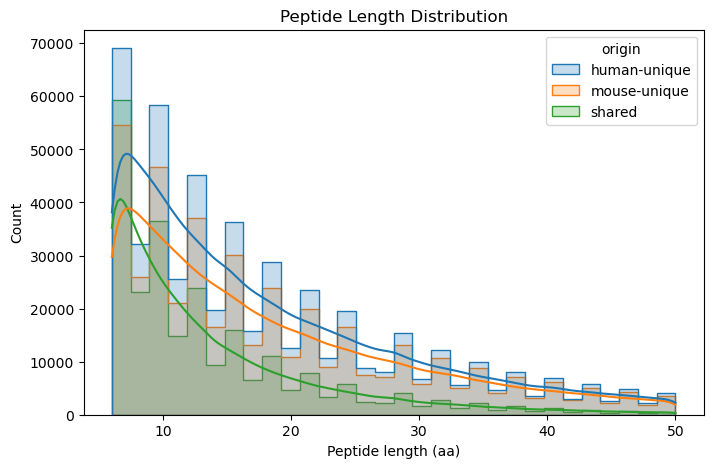

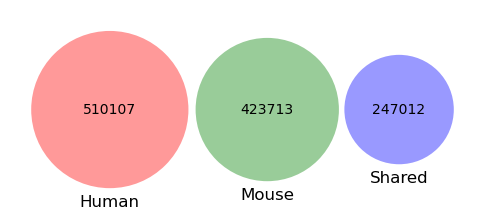

In [13]:
# Peptide length distribution
df_peptides['length'] = df_peptides['peptide'].str.len()
plt.figure(figsize=(8,5))
sns.histplot(data=df_peptides, x='length', hue='origin', bins=30, kde=True, element="step")
plt.title("Peptide Length Distribution")
plt.xlabel("Peptide length (aa)")
plt.ylabel("Count")
plt.show()

# Venn diagram
h_peps = set(df_peptides.query("origin=='human-unique'")['peptide'])
m_peps = set(df_peptides.query("origin=='mouse-unique'")['peptide'])
s_peps = set(df_peptides.query("origin=='shared'")['peptide'])
plt.figure(figsize=(6,6))
venn3([h_peps, m_peps, s_peps], set_labels=("Human","Mouse","Shared"))
plt.show()


In [14]:
## Create file that denotes how many peptides (HU, MU, SH) belong to each protein 
import pandas as pd

# Helper to get root ID
def get_root(pid):
    return pid.split("_")[0] if "_" in pid else pid

# Initialize records list
summary_records = []

# Combine all protein dictionaries
all_proteins = set(list(human_prot_peps.keys()) + list(mouse_prot_peps.keys()) + list(shared_prot_peps.keys()))

for pid in all_proteins:
    root = get_root(pid)
    
    n_human = len(human_prot_peps.get(f"{root}_HUMAN", set()))
    n_mouse = len(mouse_prot_peps.get(f"{root}_MOUSE", set()))
    n_shared = len(shared_prot_peps.get(f"{root}_SHARED", set()))
    
    summary_records.append({
        "root": root,
        "n_human_unique_peptides": n_human,
        "n_mouse_unique_peptides": n_mouse,
        "n_shared_peptides": n_shared
    })

# Build DataFrame
df_peptide_summary = pd.DataFrame(summary_records)

# Optional: remove duplicate roots
df_peptide_summary = df_peptide_summary.groupby("root").max().reset_index()

df_peptide_summary.to_csv("peptide_summary.tsv", sep="\t", index=False)

# Quick look
df_peptide_summary.head()


,root,n_human_unique_peptides,n_mouse_unique_peptides,n_shared_peptides
0,10D1B,0,9,1
1,10H28,0,13,0
2,10P22,0,9,0
3,1433B,3,3,21
4,1433F,3,2,22


In [15]:
import numpy as np

df = df_peptide_summary.copy()

# Calculate the human proportion
df['human_ratio'] = df['n_human_unique_peptides'] / (
    df['n_human_unique_peptides'] + df['n_mouse_unique_peptides']
)

# Default to NaN for Correction_Type
df['Correction_Type'] = np.nan

# 1. Remove: human_unique == 0 and shared == 0
df.loc[
    (df['n_human_unique_peptides'] == 0) & (df['n_shared_peptides'] == 0),
    'Correction_Type'
] = 'Remove'

# 2. No_Correction: shared == 0
df.loc[
    (df['n_shared_peptides'] == 0) & df['Correction_Type'].isna(),
    'Correction_Type'
] = 'No_Correction'

# 3. Protein_Specific: shared != 0 and ratio between 0.45–0.55
df.loc[
    (df['n_shared_peptides'] != 0)
    & (df['human_ratio'].between(0.45, 0.55, inclusive='both')),
    'Correction_Type'
] = 'Protein_Specific'

# 4. Overall_HK: shared != 0 and ratio < 0.45 or > 0.55
df.loc[
    (df['n_shared_peptides'] != 0)
    & ~df['human_ratio'].between(0.45, 0.55, inclusive='both'),
    'Correction_Type'
] = 'Overall_HK'

# Optional: drop helper column
df.drop(columns='human_ratio', inplace=True)
df.to_csv("assignment_table.tsv", sep="\t", index=False)
df


,root,n_human_unique_peptides,n_mouse_unique_peptides,n_shared_peptides,Correction_Type
0,10D1B,0,9,1,Overall_HK
1,10H28,0,13,0,Remove
2,10P22,0,9,0,Remove
3,1433B,3,3,21,Protein_Specific
4,1433F,3,2,22,Overall_HK
...,...,...,...,...,...
21194,ZY11A,60,27,73,Overall_HK
21195,ZY11B,11,11,47,Protein_Specific
21196,ZYX,23,23,8,Protein_Specific
21197,ZZEF1,130,117,88,Protein_Specific


In [16]:
# Check for any missing Correction_Type values
missing = df[df['Correction_Type'].isna()]

if missing.empty:
    print("✅ All roots have been assigned a Correction_Type.")
else:
    print("⚠️ Some roots were not categorized:")
    display(missing)


✅ All roots have been assigned a Correction_Type.
